<a href="https://colab.research.google.com/github/rennanpo/deeplearning/blob/main/deepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

from sklearn.metrics import confusion_matrix, classification_report

import kagglehub


In [ ]:
# Baixando e extraindo o dataset do Kaggle
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

# Caminho das pastas
data_path = os.path.join(path, "chest_xray")

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.ImageFolder(os.path.join(data_path, "train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_path, "val"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(data_path, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler

# Contar a distribuição de classes
train_labels = [label for _, label in train_dataset]
label_counts = Counter(train_labels)
print("Distribuição de classes no treino:", label_counts)

# Calcular pesos por classe para a loss function
total = sum(label_counts.values())
class_weights = [total / label_counts[i] for i in range(len(label_counts))]
weights_tensor = torch.FloatTensor(class_weights).to(device)

# Criar a loss function com pesos
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# Calcular peso individual para cada amostra (usado pelo sampler)
sample_weights = [1.0 / label_counts[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_dataset), replacement=True)

# Criar novo train_loader com o sampler balanceado
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)


Distribuição de classes no treino: Counter({1: 3875, 0: 1341})


In [ ]:
class PneumoniaCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(PneumoniaCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(128 * 16 * 16, 2)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


In [ ]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=10):
    train_loss, val_loss = [], []
    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            epoch_loss += loss.item()

        train_loss.append(epoch_loss / len(train_loader))
        train_acc.append(correct / total)

        # Validação
        model.eval()
        correct, total, epoch_loss = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                epoch_loss += loss.item()
        val_loss.append(epoch_loss / len(val_loader))
        val_acc.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc={train_acc[-1]:.4f}, Val Acc={val_acc[-1]:.4f}")

    return train_loss, val_loss, train_acc, val_acc


In [ ]:
from itertools import product

def run_grid_search(learning_rates, dropouts, weight_decays, epochs=5):
    best_acc = 0.0
    best_params = {}

    for lr, dr, wd in product(learning_rates, dropouts, weight_decays):
        print(f"\n🔍 Testando combinação: lr={lr}, dropout={dr}, weight_decay={wd}")
        model = PneumoniaCNN(dropout_rate=dr).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

        _, _, _, val_acc = train_model(model, criterion, optimizer, train_loader, val_loader, epochs)
        final_val_acc = val_acc[-1]
        print(f"📊 Acurácia final de validação: {final_val_acc:.4f}")

        if final_val_acc > best_acc:
            best_acc = final_val_acc
            best_params = {'lr': lr, 'dropout': dr, 'weight_decay': wd}

    print(f"\n✅ Melhor combinação: {best_params} com acurácia {best_acc:.4f}")
    return best_params


In [ ]:
# Executar Grid Search
best_hyperparams = run_grid_search(
    learning_rates=[0.001, 0.0005],
    dropouts=[0.3, 0.5],
    weight_decays=[1e-4, 1e-5],
    epochs=5
)

# Treinamento final com melhores parâmetros
model = PneumoniaCNN(dropout_rate=best_hyperparams['dropout']).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=best_hyperparams['lr'], weight_decay=best_hyperparams['weight_decay'])

train_loss, val_loss, train_acc, val_acc = train_model(model, criterion, optimizer, train_loader, val_loader)



🔍 Testando combinação: lr=0.001, dropout=0.3, weight_decay=0.0001
Epoch 1: Train Acc=0.9273, Val Acc=0.8125
Epoch 2: Train Acc=0.9590, Val Acc=0.8750
Epoch 3: Train Acc=0.9595, Val Acc=0.5000
Epoch 4: Train Acc=0.9668, Val Acc=0.8750
Epoch 5: Train Acc=0.9795, Val Acc=0.9375
📊 Acurácia final de validação: 0.9375

🔍 Testando combinação: lr=0.001, dropout=0.3, weight_decay=1e-05
Epoch 1: Train Acc=0.9233, Val Acc=0.5625
Epoch 2: Train Acc=0.9511, Val Acc=0.8750
Epoch 3: Train Acc=0.9670, Val Acc=0.9375
Epoch 4: Train Acc=0.9718, Val Acc=1.0000
Epoch 5: Train Acc=0.9726, Val Acc=0.9375
📊 Acurácia final de validação: 0.9375

🔍 Testando combinação: lr=0.001, dropout=0.5, weight_decay=0.0001
Epoch 1: Train Acc=0.9304, Val Acc=0.9375
Epoch 2: Train Acc=0.9549, Val Acc=0.8750
Epoch 3: Train Acc=0.9628, Val Acc=0.8750
Epoch 4: Train Acc=0.9645, Val Acc=0.8750
Epoch 5: Train Acc=0.9726, Val Acc=0.5625
📊 Acurácia final de validação: 0.5625

🔍 Testando combinação: lr=0.001, dropout=0.5, weight_de

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

true_labels, pred_labels = evaluate(model, test_loader)

print(classification_report(true_labels, pred_labels, target_names=train_dataset.classes))

cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


NameError: name 'model' is not defined

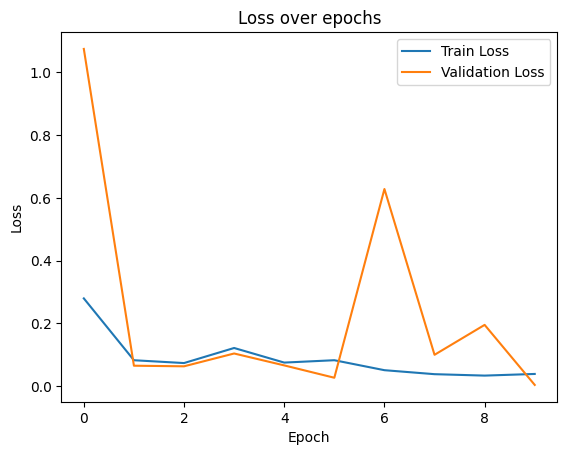

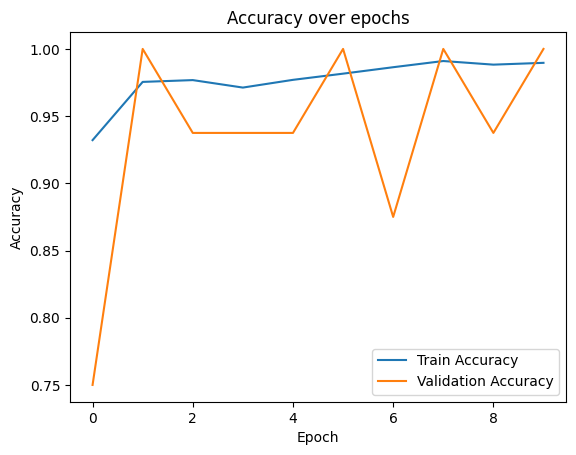

In [ ]:
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
resnet = models.resnet18(pretrained=True)
resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=0.001)

train_loss, val_loss, train_acc, val_acc = train_model(resnet, criterion, optimizer, train_loader, val_loader)

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('ResNet18 - Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('ResNet18 - Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
resnet = models.resnet18(pretrained=True)
resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=0.001)

train_loss, val_loss, train_acc, val_acc = train_model(resnet, criterion, optimizer, train_loader, val_loader)

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('ResNet18 - Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('ResNet18 - Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
def show_predictions(model, loader, dataset, correct=True, n=1):
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(len(preds)):
                is_correct = (preds[i] == labels[i])
                if is_correct == correct:
                    plt.imshow(inputs[i][0].cpu(), cmap='gray')
                    plt.title(f"Predito: {dataset.classes[preds[i]]} | Real: {dataset.classes[labels[i]]}")
                    plt.axis('off')
                    plt.show()
                    shown += 1
                    if shown >= n:
                        return


In [ ]:
print("🎯 Exemplo de classificação correta:")
show_predictions(model, test_loader, train_dataset, correct=True, n=1)

print("❌ Exemplo de classificação incorreta:")
show_predictions(model, test_loader, train_dataset, correct=False, n=1)


In [ ]:
def visualize_feature_maps(model, image_tensor):
    model.eval()
    layers = list(model.conv_layers.children())
    x = image_tensor.unsqueeze(0).to(device)  # (1, C, H, W)

    with torch.no_grad():
        for i, layer in enumerate(layers):
            x = layer(x)
            if isinstance(layer, nn.ReLU) or isinstance(layer, nn.MaxPool2d):
                # Selecionar alguns canais para visualização
                fig, axes = plt.subplots(1, 6, figsize=(15, 5))
                for j in range(6):
                    if j < x.shape[1]:
                        axes[j].imshow(x[0, j].cpu(), cmap='gray')
                        axes[j].axis('off')
                        axes[j].set_title(f"Mapa {j}")
                plt.suptitle(f"Feature Maps após camada {i}: {layer.__class__.__name__}")
                plt.show()


In [ ]:
# Pegar uma imagem da base de teste
sample_img, _ = test_dataset[0]

# Visualizar feature maps
visualize_feature_maps(model, sample_img)


In [ ]:
from collections import Counter
print("Treino:", Counter([label for _, label in train_dataset]))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

from sklearn.metrics import confusion_matrix, classification_report

import kagglehub


In [ ]:
# Baixando e extraindo o dataset do Kaggle
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

# Caminho das pastas
data_path = os.path.join(path, "chest_xray")

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.ImageFolder(os.path.join(data_path, "train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_path, "val"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(data_path, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler

# Contar a distribuição de classes
train_labels = [label for _, label in train_dataset]
label_counts = Counter(train_labels)
print("Distribuição de classes no treino:", label_counts)

# Calcular pesos por classe para a loss function
total = sum(label_counts.values())
class_weights = [total / label_counts[i] for i in range(len(label_counts))]
weights_tensor = torch.FloatTensor(class_weights).to(device)

# Criar a loss function com pesos
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# Calcular peso individual para cada amostra (usado pelo sampler)
sample_weights = [1.0 / label_counts[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_dataset), replacement=True)

# Criar novo train_loader com o sampler balanceado
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)


Distribuição de classes no treino: Counter({1: 3875, 0: 1341})


In [ ]:
class PneumoniaCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(PneumoniaCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(128 * 16 * 16, 2)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


In [ ]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=10):
    train_loss, val_loss = [], []
    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            epoch_loss += loss.item()

        train_loss.append(epoch_loss / len(train_loader))
        train_acc.append(correct / total)

        # Validação
        model.eval()
        correct, total, epoch_loss = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                epoch_loss += loss.item()
        val_loss.append(epoch_loss / len(val_loader))
        val_acc.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc={train_acc[-1]:.4f}, Val Acc={val_acc[-1]:.4f}")

    return train_loss, val_loss, train_acc, val_acc


In [ ]:
from itertools import product

def run_grid_search(learning_rates, dropouts, weight_decays, epochs=5):
    best_acc = 0.0
    best_params = {}

    for lr, dr, wd in product(learning_rates, dropouts, weight_decays):
        print(f"\n🔍 Testando combinação: lr={lr}, dropout={dr}, weight_decay={wd}")
        model = PneumoniaCNN(dropout_rate=dr).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

        _, _, _, val_acc = train_model(model, criterion, optimizer, train_loader, val_loader, epochs)
        final_val_acc = val_acc[-1]
        print(f"📊 Acurácia final de validação: {final_val_acc:.4f}")

        if final_val_acc > best_acc:
            best_acc = final_val_acc
            best_params = {'lr': lr, 'dropout': dr, 'weight_decay': wd}

    print(f"\n✅ Melhor combinação: {best_params} com acurácia {best_acc:.4f}")
    return best_params


In [ ]:
# Executar Grid Search
best_hyperparams = run_grid_search(
    learning_rates=[0.001, 0.0005],
    dropouts=[0.3, 0.5],
    weight_decays=[1e-4, 1e-5],
    epochs=5
)

# Treinamento final com melhores parâmetros
model = PneumoniaCNN(dropout_rate=best_hyperparams['dropout']).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=best_hyperparams['lr'], weight_decay=best_hyperparams['weight_decay'])

train_loss, val_loss, train_acc, val_acc = train_model(model, criterion, optimizer, train_loader, val_loader)



🔍 Testando combinação: lr=0.001, dropout=0.3, weight_decay=0.0001
Epoch 1: Train Acc=0.9350, Val Acc=0.8750
Epoch 2: Train Acc=0.9622, Val Acc=0.9375
Epoch 3: Train Acc=0.9574, Val Acc=0.8750
Epoch 4: Train Acc=0.9772, Val Acc=0.8750
Epoch 5: Train Acc=0.9774, Val Acc=0.9375
📊 Acurácia final de validação: 0.9375

🔍 Testando combinação: lr=0.001, dropout=0.3, weight_decay=1e-05
Epoch 1: Train Acc=0.9333, Val Acc=0.7500
Epoch 2: Train Acc=0.9574, Val Acc=1.0000
Epoch 3: Train Acc=0.9699, Val Acc=0.8750
Epoch 4: Train Acc=0.9758, Val Acc=0.6875
Epoch 5: Train Acc=0.9745, Val Acc=0.9375
📊 Acurácia final de validação: 0.9375

🔍 Testando combinação: lr=0.001, dropout=0.5, weight_decay=0.0001
Epoch 1: Train Acc=0.9363, Val Acc=0.8125
Epoch 2: Train Acc=0.9582, Val Acc=1.0000
Epoch 3: Train Acc=0.9638, Val Acc=1.0000
Epoch 4: Train Acc=0.9649, Val Acc=0.9375
Epoch 5: Train Acc=0.9745, Val Acc=1.0000
📊 Acurácia final de validação: 1.0000

🔍 Testando combinação: lr=0.001, dropout=0.5, weight_de

              precision    recall  f1-score   support

      NORMAL       1.00      0.29      0.45       234
   PNEUMONIA       0.70      1.00      0.82       390

    accuracy                           0.73       624
   macro avg       0.85      0.65      0.64       624
weighted avg       0.81      0.73      0.68       624



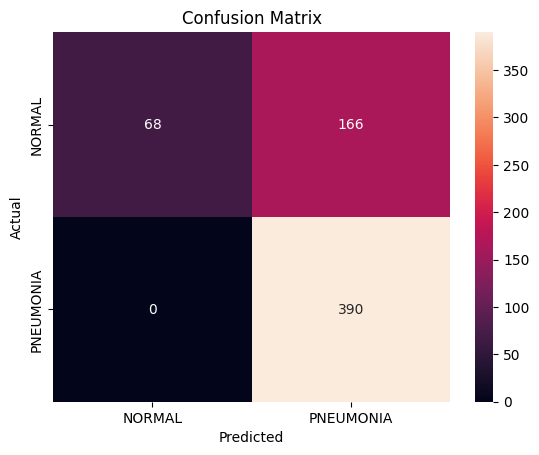

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

true_labels, pred_labels = evaluate(model, test_loader)

print(classification_report(true_labels, pred_labels, target_names=train_dataset.classes))

cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


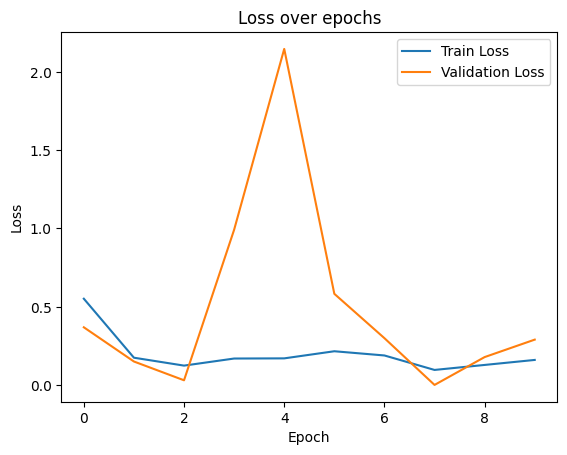

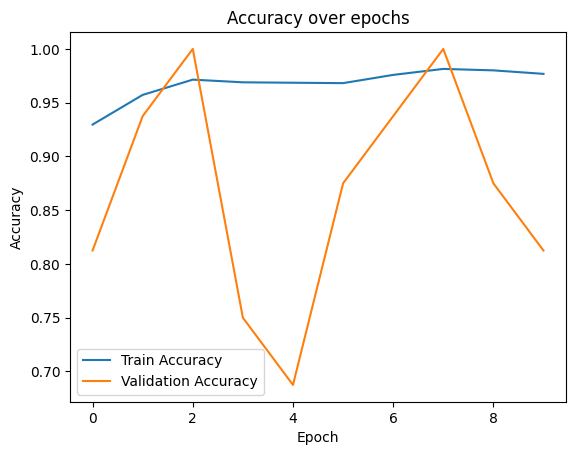

In [ ]:
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Epoch 1: Train Acc=0.9521, Val Acc=0.7500
Epoch 2: Train Acc=0.9795, Val Acc=0.6250
Epoch 3: Train Acc=0.9833, Val Acc=0.9375
Epoch 4: Train Acc=0.9891, Val Acc=0.6875
Epoch 5: Train Acc=0.9906, Val Acc=1.0000
Epoch 6: Train Acc=0.9964, Val Acc=1.0000
Epoch 7: Train Acc=0.9942, Val Acc=0.9375
Epoch 8: Train Acc=0.9952, Val Acc=0.8125
Epoch 9: Train Acc=0.9935, Val Acc=0.9375
Epoch 10: Train Acc=0.9935, Val Acc=0.9375


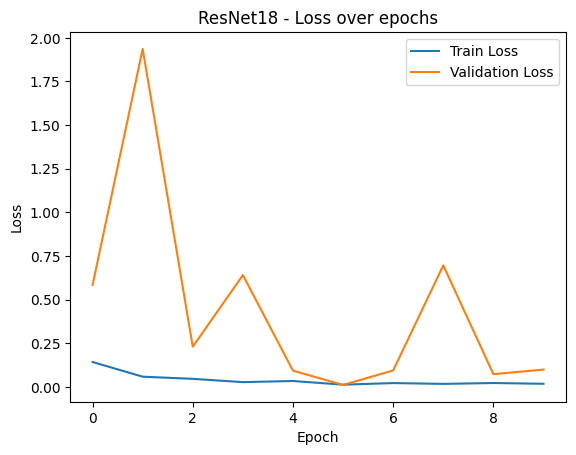

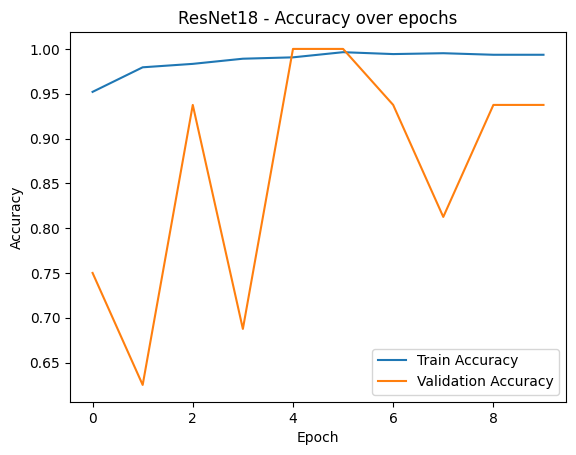

In [ ]:
resnet = models.resnet18(pretrained=True)
resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=0.001)

train_loss, val_loss, train_acc, val_acc = train_model(resnet, criterion, optimizer, train_loader, val_loader)

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('ResNet18 - Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('ResNet18 - Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


              precision    recall  f1-score   support

      NORMAL       0.92      0.68      0.78       234
   PNEUMONIA       0.84      0.96      0.90       390

    accuracy                           0.86       624
   macro avg       0.88      0.82      0.84       624
weighted avg       0.87      0.86      0.85       624



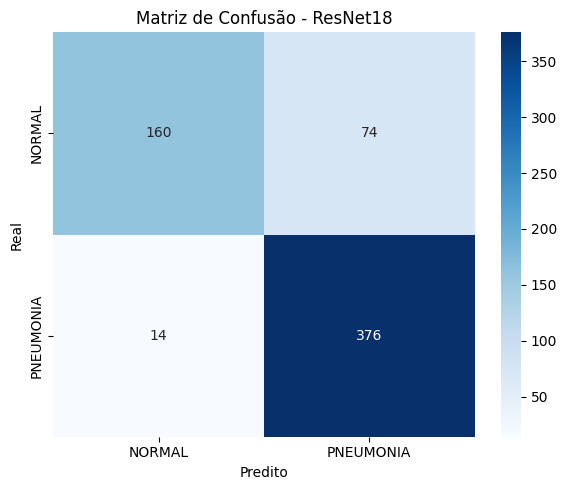

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Avaliação
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

# Obter verdadeiros e preditos
true_labels, pred_labels = evaluate_model(resnet, test_loader)

# Gerar matriz
cm = confusion_matrix(true_labels, pred_labels)
classes = train_dataset.classes  # ["NORMAL", "PNEUMONIA"]
print(classification_report(true_labels, pred_labels, target_names=train_dataset.classes))
# Plotar
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - ResNet18")
plt.tight_layout()
plt.show()


In [ ]:
def show_predictions(model, loader, dataset, correct=True, n=1):
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(len(preds)):
                is_correct = (preds[i] == labels[i])
                if is_correct == correct:
                    plt.imshow(inputs[i][0].cpu(), cmap='gray')
                    plt.title(f"Predito: {dataset.classes[preds[i]]} | Real: {dataset.classes[labels[i]]}")
                    plt.axis('off')
                    plt.show()
                    shown += 1
                    if shown >= n:
                        return


🎯 Exemplo de classificação correta:


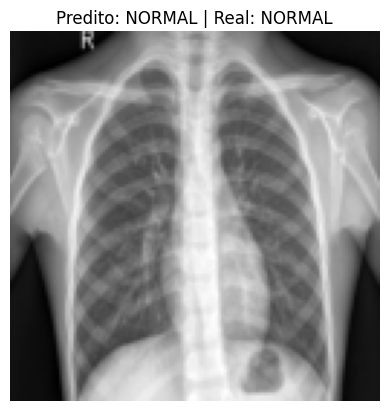

❌ Exemplo de classificação incorreta:


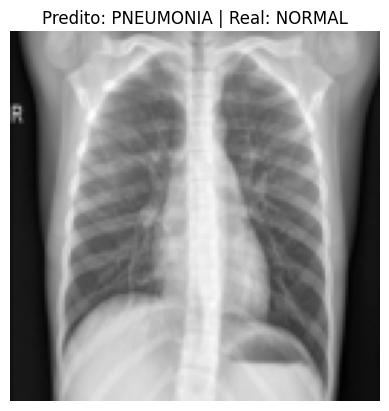

In [ ]:
print("🎯 Exemplo de classificação correta:")
show_predictions(model, test_loader, train_dataset, correct=True, n=1)

print("❌ Exemplo de classificação incorreta:")
show_predictions(model, test_loader, train_dataset, correct=False, n=1)


In [ ]:
def visualize_feature_maps(model, image_tensor):
    model.eval()
    layers = list(model.conv_layers.children())
    x = image_tensor.unsqueeze(0).to(device)  # (1, C, H, W)

    with torch.no_grad():
        for i, layer in enumerate(layers):
            x = layer(x)
            if isinstance(layer, nn.ReLU) or isinstance(layer, nn.MaxPool2d):
                # Selecionar alguns canais para visualização
                fig, axes = plt.subplots(1, 6, figsize=(15, 5))
                for j in range(6):
                    if j < x.shape[1]:
                        axes[j].imshow(x[0, j].cpu(), cmap='gray')
                        axes[j].axis('off')
                        axes[j].set_title(f"Mapa {j}")
                plt.suptitle(f"Feature Maps após camada {i}: {layer.__class__.__name__}")
                plt.show()


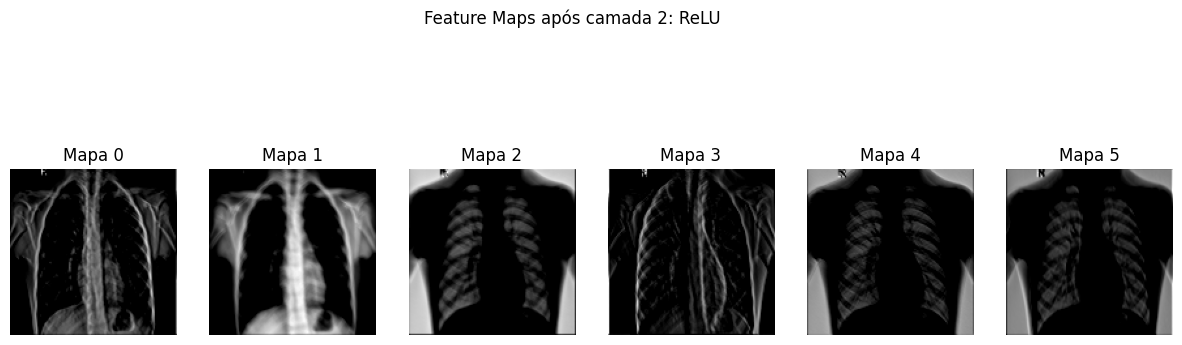

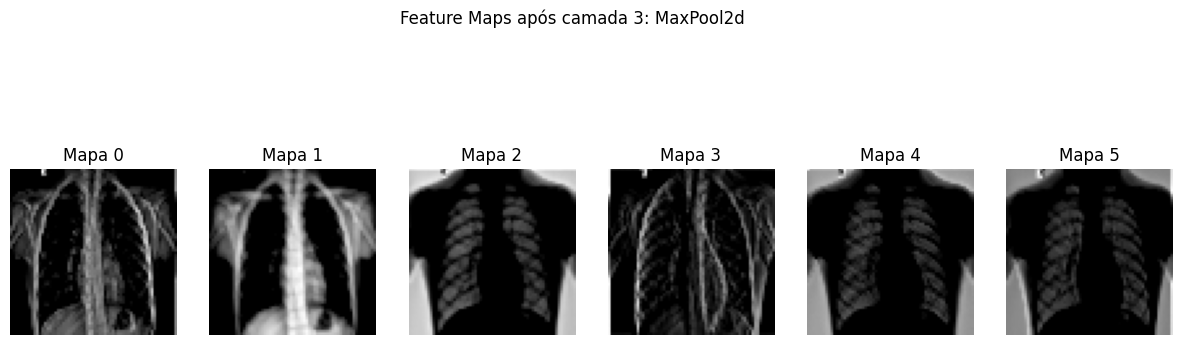

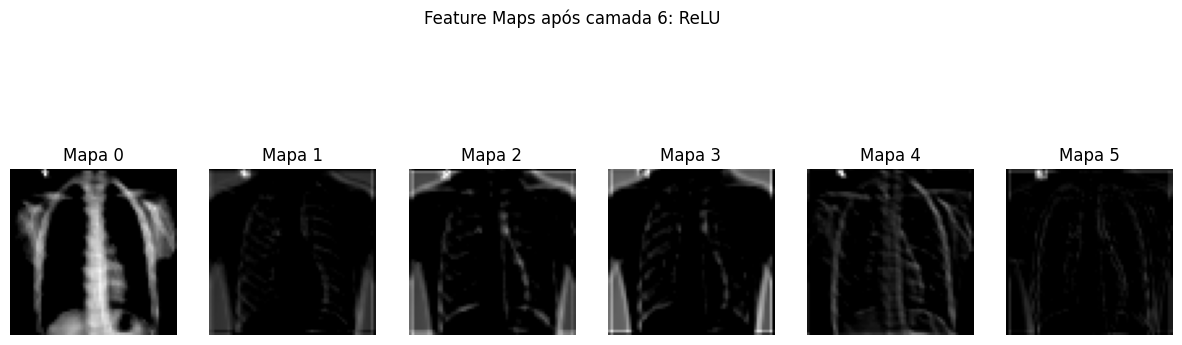

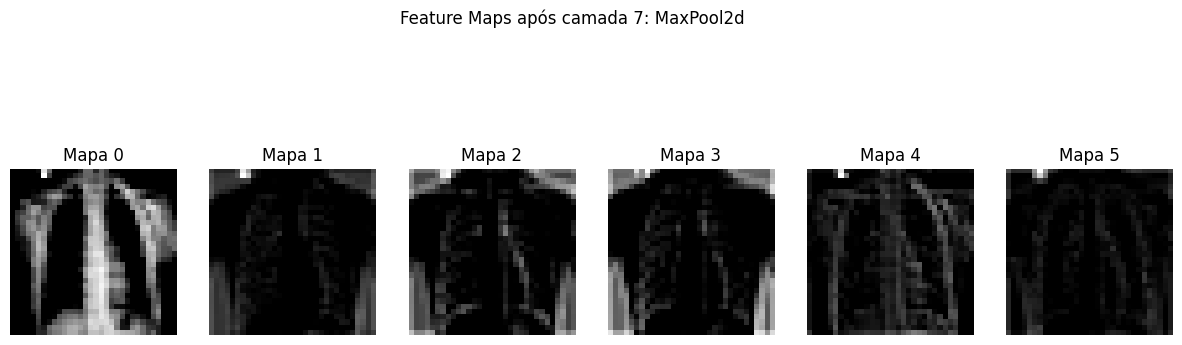

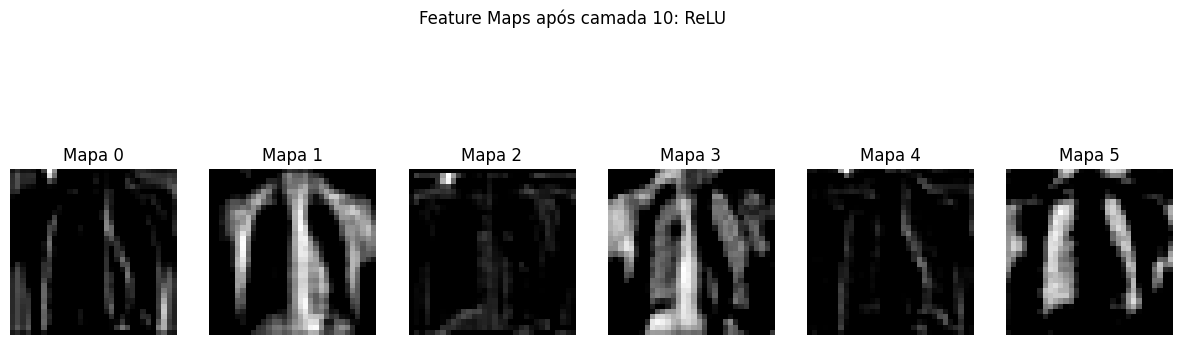

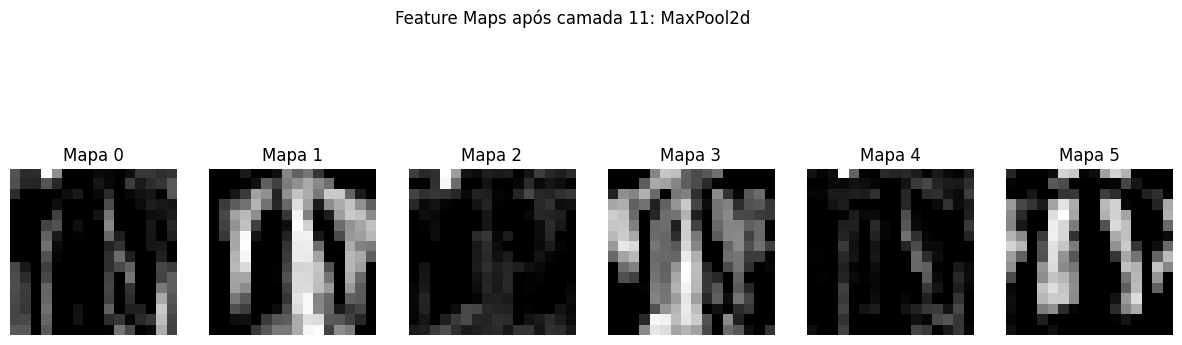

In [ ]:
# Pegar uma imagem da base de teste
sample_img, _ = test_dataset[0]

# Visualizar feature maps
visualize_feature_maps(model, sample_img)
